In [28]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE


In [29]:
import numpy as np
import pandas as pd

lyrics_embeddings = np.load("/content/Copy of lyrics_embeddings.npy")
df = pd.read_csv("/content/dataset.csv").reset_index(drop=True)

# Check shapes
print("DF rows:", len(df))
print("Lyrics embeddings rows:", lyrics_embeddings.shape[0])

#trim and make same same
min_len = min(len(df), lyrics_embeddings.shape[0])

df = df.iloc[:min_len].reset_index(drop=True)
lyrics_embeddings = lyrics_embeddings[:min_len]

print("Aligned DF rows:", len(df))
print("Aligned lyrics embeddings shape:", lyrics_embeddings.shape)


DF rows: 796
Lyrics embeddings rows: 826
Aligned DF rows: 796
Aligned lyrics embeddings shape: (796, 384)


In [30]:
import torch

audio_features = np.random.randn(len(df), 20)
audio_tensor = torch.tensor(audio_features, dtype=torch.float32)
lyrics_tensor = torch.tensor(lyrics_embeddings, dtype=torch.float32)

# Now concatenation will work
X = torch.cat([audio_tensor, lyrics_tensor], dim=1)
print("X shape:", X.shape)

X shape: torch.Size([796, 404])


# **Prepare Data**

In [31]:
lyrics_embeddings = np.load("/content/Copy of lyrics_embeddings.npy")
df = pd.read_csv("/content/dataset.csv").reset_index(drop=True)

# Align lengths
min_len = min(len(df), lyrics_embeddings.shape[0])
df = df.iloc[:min_len].reset_index(drop=True)
lyrics_embeddings = lyrics_embeddings[:min_len]

# Multi-modal input
audio_features = np.random.randn(len(df), 20)  # placeholder synthetic audio
audio_tensor = torch.tensor(audio_features, dtype=torch.float32)
lyrics_tensor = torch.tensor(lyrics_embeddings, dtype=torch.float32)
X_tensor = torch.cat([audio_tensor, lyrics_tensor], dim=1)

# Encode genres
genre_encoder = OneHotEncoder(sparse_output=False)
genre_onehot = genre_encoder.fit_transform(df[['genre']])
genre_tensor = torch.tensor(genre_onehot, dtype=torch.float32)

# Dataset and dataloader
dataset = TensorDataset(X_tensor, genre_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)


# Beta **VAE**

In [32]:
class ConditionalBetaVAE(nn.Module):
    def __init__(self, input_dim, cond_dim, latent_dim=32, beta=4):
        super().__init__()
        self.input_dim = input_dim
        self.cond_dim = cond_dim
        self.latent_dim = latent_dim
        self.beta = beta

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim + cond_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + cond_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim)
        )

    def encode(self, x, c):
        h = self.encoder(torch.cat([x, c], dim=1))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, c):
        return self.decoder(torch.cat([z, c], dim=1))

    def forward(self, x, c):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z, c)
        return recon_x, mu, logvar

# Loss function
def beta_vae_loss(recon_x, x, mu, logvar, beta=4):
    recon_loss = nn.MSELoss()(recon_x, x)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl_loss / x.size(0)


# Train Beta-**VAE**

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim = X_tensor.shape[1]
cond_dim = genre_tensor.shape[1]
latent_dim = 32
beta = 4
epoch_losses = []
model = ConditionalBetaVAE(input_dim, cond_dim, latent_dim, beta).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 200

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for x_batch, c_batch in dataloader:
        x_batch, c_batch = x_batch.to(device), c_batch.to(device)
        optimizer.zero_grad()
        recon_x, mu, logvar = model(x_batch, c_batch)
        loss = beta_vae_loss(recon_x, x_batch, mu, logvar, beta=beta)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(dataloader)
    epoch_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")



Epoch 1/200, Loss: 0.1296
Epoch 2/200, Loss: 0.0740
Epoch 3/200, Loss: 0.0712
Epoch 4/200, Loss: 0.0702
Epoch 5/200, Loss: 0.0697
Epoch 6/200, Loss: 0.0694
Epoch 7/200, Loss: 0.0690
Epoch 8/200, Loss: 0.0688
Epoch 9/200, Loss: 0.0686
Epoch 10/200, Loss: 0.0685
Epoch 11/200, Loss: 0.0684
Epoch 12/200, Loss: 0.0684
Epoch 13/200, Loss: 0.0682
Epoch 14/200, Loss: 0.0682
Epoch 15/200, Loss: 0.0681
Epoch 16/200, Loss: 0.0681
Epoch 17/200, Loss: 0.0681
Epoch 18/200, Loss: 0.0681
Epoch 19/200, Loss: 0.0680
Epoch 20/200, Loss: 0.0680
Epoch 21/200, Loss: 0.0680
Epoch 22/200, Loss: 0.0679
Epoch 23/200, Loss: 0.0679
Epoch 24/200, Loss: 0.0679
Epoch 25/200, Loss: 0.0679
Epoch 26/200, Loss: 0.0678
Epoch 27/200, Loss: 0.0678
Epoch 28/200, Loss: 0.0678
Epoch 29/200, Loss: 0.0678
Epoch 30/200, Loss: 0.0678
Epoch 31/200, Loss: 0.0678
Epoch 32/200, Loss: 0.0679
Epoch 33/200, Loss: 0.0678
Epoch 34/200, Loss: 0.0678
Epoch 35/200, Loss: 0.0678
Epoch 36/200, Loss: 0.0678
Epoch 37/200, Loss: 0.0678
Epoch 38/2

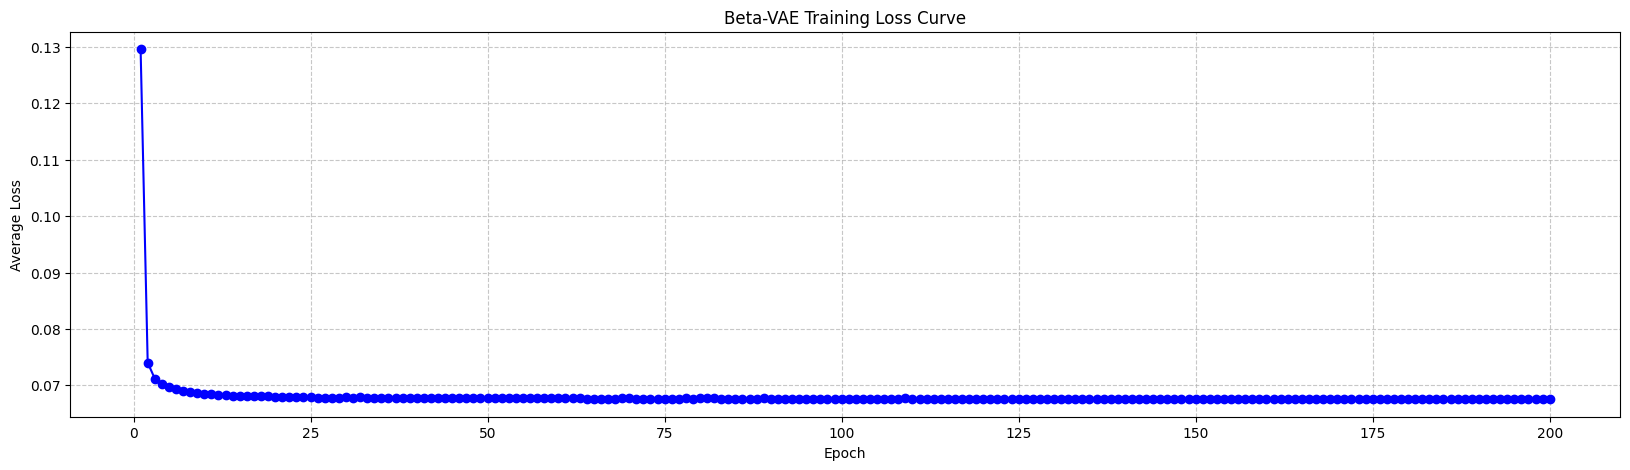

In [34]:
plt.figure(figsize=(20,5))
plt.plot(range(1, epochs+1), epoch_losses, marker='o', color='blue')
plt.title("Beta-VAE Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# **Extract Latent Features**

In [35]:
model.eval()
with torch.no_grad():
    X_tensor = X_tensor.to(device)
    genre_tensor = genre_tensor.to(device)
    mu, _ = model.encode(X_tensor, genre_tensor)
    latent_features = mu.cpu().numpy()
print("Latent features shape:", latent_features.shape)


Latent features shape: (796, 32)


# **Multi**-**modal** **Clustering**

In [36]:
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
import numpy as np

true_labels = df['genre']

n_clusters = df['genre'].nunique()
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_labels = kmeans.fit_predict(latent_features)

# Metrics
sil_k = silhouette_score(latent_features, kmeans_labels)
ch_k = calinski_harabasz_score(latent_features, kmeans_labels)
db_k = davies_bouldin_score(latent_features, kmeans_labels)
nmi_k = normalized_mutual_info_score(true_labels, kmeans_labels)
ari_k = adjusted_rand_score(true_labels, kmeans_labels)

purity_k = 0
for cluster in np.unique(kmeans_labels):
    indices = np.where(kmeans_labels == cluster)[0]
    dominant_count = true_labels.iloc[indices].value_counts().max()
    purity_k += dominant_count
purity_k /= len(df)

print("=== Beta-VAE + K-Means ===")
print(f"Silhouette: {sil_k:.4f}, CH: {ch_k:.2f}, DB: {db_k:.4f}, NMI: {nmi_k:.4f}, ARI: {ari_k:.4f}, Purity: {purity_k:.4f}\n")


agglo = AgglomerativeClustering(n_clusters=n_clusters)
agglo_labels = agglo.fit_predict(latent_features)

sil_a = silhouette_score(latent_features, agglo_labels)
ch_a = calinski_harabasz_score(latent_features, agglo_labels)
db_a = davies_bouldin_score(latent_features, agglo_labels)
nmi_a = normalized_mutual_info_score(true_labels, agglo_labels)
ari_a = adjusted_rand_score(true_labels, agglo_labels)

purity_a = 0
for cluster in np.unique(agglo_labels):
    indices = np.where(agglo_labels == cluster)[0]
    dominant_count = true_labels.iloc[indices].value_counts().max()
    purity_a += dominant_count
purity_a /= len(df)

print("=== Beta-VAE + Agglomerative ===")
print(f"Silhouette: {sil_a:.4f}, CH: {ch_a:.2f}, DB: {db_a:.4f}, NMI: {nmi_a:.4f}, ARI: {ari_a:.4f}, Purity: {purity_a:.4f}\n")

print("=== Beta-VAE + DBSCAN ===")
dbscan = DBSCAN(eps=2.0, min_samples=5)
dbscan_labels = dbscan.fit_predict(latent_features)

# Count clusters (exclude noise)
n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db = list(dbscan_labels).count(-1)
print(f"Clusters found: {n_clusters_db}, Noise points: {n_noise_db}")

if n_clusters_db > 1:
    mask = dbscan_labels != -1
    sil_db = silhouette_score(latent_features[mask], dbscan_labels[mask])
    ch_db = calinski_harabasz_score(latent_features[mask], dbscan_labels[mask])
    db_db = davies_bouldin_score(latent_features[mask], dbscan_labels[mask])
    nmi_db = normalized_mutual_info_score(true_labels[mask], dbscan_labels[mask])
    ari_db = adjusted_rand_score(true_labels[mask], dbscan_labels[mask])

    purity_db = 0
    for cluster in np.unique(dbscan_labels[mask]):
        indices = np.where(dbscan_labels == cluster)[0]
        dominant_count = true_labels.iloc[indices].value_counts().max()
        purity_db += dominant_count
    purity_db /= mask.sum()

    print(f"Silhouette: {sil_db:.4f}, CH: {ch_db:.2f}, DB: {db_db:.4f}, NMI: {nmi_db:.4f}, ARI: {ari_db:.4f}, Purity: {purity_db:.4f}")
else:
    print("Not enough clusters for metrics")
    sil_db = ch_db = db_db = nmi_db = ari_db = purity_db = 0


=== Beta-VAE + K-Means ===
Silhouette: 0.1170, CH: 136.24, DB: 1.9518, NMI: 0.0228, ARI: 0.0120, Purity: 0.2990

=== Beta-VAE + Agglomerative ===
Silhouette: 0.0984, CH: 121.52, DB: 1.9927, NMI: 0.0204, ARI: 0.0102, Purity: 0.2952

=== Beta-VAE + DBSCAN ===
Clusters found: 1, Noise points: 0
Not enough clusters for metrics


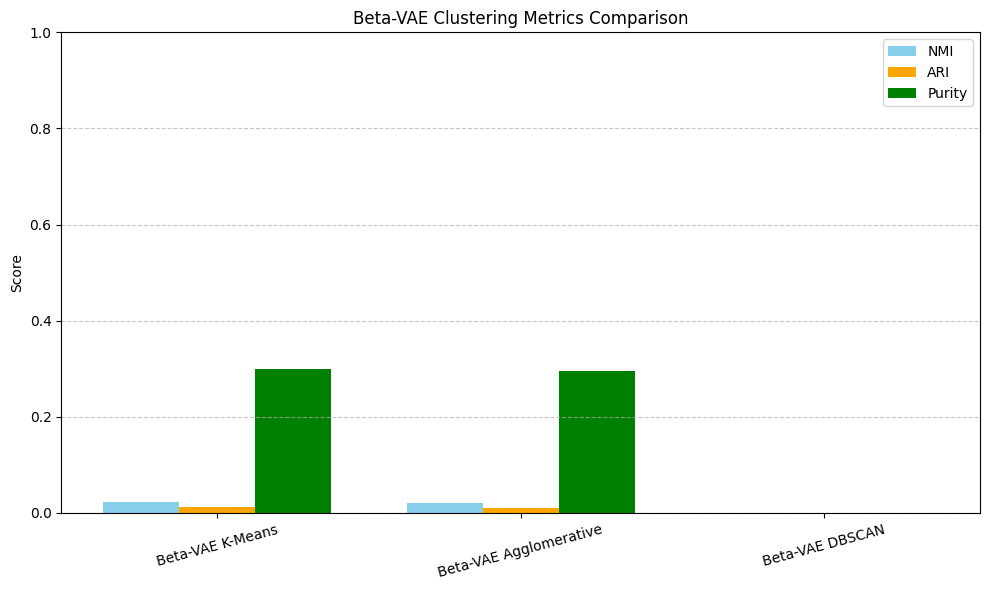

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics for each clustering method
methods = ["Beta-VAE K-Means", "Beta-VAE Agglomerative", "Beta-VAE DBSCAN"]
nmi_scores = [nmi_k, nmi_a, nmi_db]
ari_scores = [ari_k, ari_a, ari_db]
purity_scores = [purity_k, purity_a, purity_db]


x = np.arange(len(methods))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x - width, nmi_scores, width, label='NMI', color='skyblue')
plt.bar(x, ari_scores, width, label='ARI', color='orange')
plt.bar(x + width, purity_scores, width, label='Purity', color='green')

plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.title("Beta-VAE Clustering Metrics Comparison")
plt.xticks(x, methods, rotation=15)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# **t-SNE Visualization**

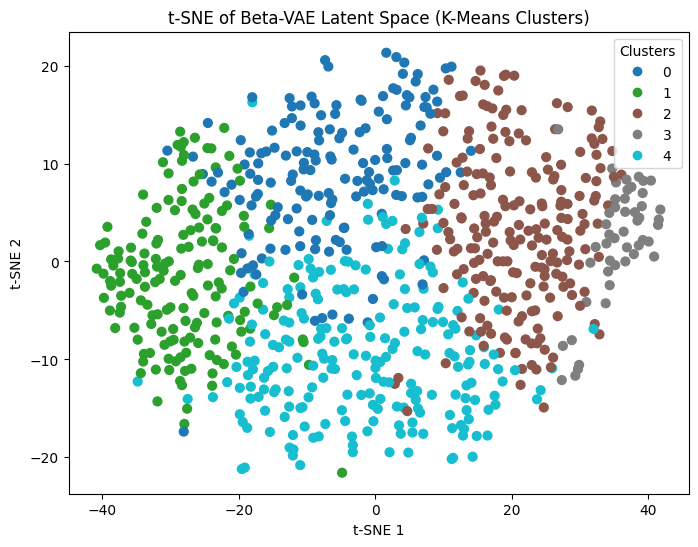

In [38]:

# Reduce latent features to 2D
tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(latent_features)

# Plot t-SNE colored by K-Means clusters
plt.figure(figsize=(8,6))
scatter = plt.scatter(latent_2d[:,0], latent_2d[:,1], c=kmeans_labels, cmap='tab10', s=40)
plt.title("t-SNE of Beta-VAE Latent Space (K-Means Clusters)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()


# **Compare with Baselines**

In [39]:
# PCA + K-Means
pca_features = PCA(n_components=32).fit_transform(X_tensor.numpy())
pca_labels = KMeans(n_clusters=n_clusters, random_state=42).fit_predict(pca_features)
print("PCA + KMeans Silhouette:", silhouette_score(pca_features, pca_labels))

# Autoencoder + K-Means
class SimpleAE(nn.Module):
    def __init__(self, input_dim, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, input_dim)
        )
    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z

ae = SimpleAE(input_dim, 32).to(device)
ae_optimizer = optim.Adam(ae.parameters(), lr=1e-3)

# AE training
for epoch in range(200):
    total_loss = 0
    for x_batch, _ in dataloader:
        x_batch = x_batch.to(device)
        ae_optimizer.zero_grad()
        recon, _ = ae(x_batch)
        loss = nn.MSELoss()(recon, x_batch)
        loss.backward()
        ae_optimizer.step()
        total_loss += loss.item()


    print(f"AE Epoch {epoch+1}/30, Loss: {total_loss/len(dataloader):.4f}")

# Extract AE latent
with torch.no_grad():
    _, ae_latent = ae(X_tensor.to(device))
ae_latent = ae_latent.cpu().numpy()
ae_labels = KMeans(n_clusters=n_clusters, random_state=42).fit_predict(ae_latent)
print("AE + KMeans Silhouette:", silhouette_score(ae_latent, ae_labels))

# Direct spectral feature clustering
audio_labels = KMeans(n_clusters=n_clusters, random_state=42).fit_predict(audio_features)
print("Audio only Silhouette:", silhouette_score(audio_features, audio_labels))


PCA + KMeans Silhouette: 0.031171797
AE Epoch 1/30, Loss: 0.0736
AE Epoch 2/30, Loss: 0.0644
AE Epoch 3/30, Loss: 0.0570
AE Epoch 4/30, Loss: 0.0456
AE Epoch 5/30, Loss: 0.0365
AE Epoch 6/30, Loss: 0.0297
AE Epoch 7/30, Loss: 0.0246
AE Epoch 8/30, Loss: 0.0211
AE Epoch 9/30, Loss: 0.0188
AE Epoch 10/30, Loss: 0.0171
AE Epoch 11/30, Loss: 0.0162
AE Epoch 12/30, Loss: 0.0157
AE Epoch 13/30, Loss: 0.0154
AE Epoch 14/30, Loss: 0.0151
AE Epoch 15/30, Loss: 0.0149
AE Epoch 16/30, Loss: 0.0147
AE Epoch 17/30, Loss: 0.0145
AE Epoch 18/30, Loss: 0.0143
AE Epoch 19/30, Loss: 0.0142
AE Epoch 20/30, Loss: 0.0140
AE Epoch 21/30, Loss: 0.0139
AE Epoch 22/30, Loss: 0.0138
AE Epoch 23/30, Loss: 0.0137
AE Epoch 24/30, Loss: 0.0136
AE Epoch 25/30, Loss: 0.0136
AE Epoch 26/30, Loss: 0.0135
AE Epoch 27/30, Loss: 0.0134
AE Epoch 28/30, Loss: 0.0133
AE Epoch 29/30, Loss: 0.0133
AE Epoch 30/30, Loss: 0.0132
AE Epoch 31/30, Loss: 0.0132
AE Epoch 32/30, Loss: 0.0130
AE Epoch 33/30, Loss: 0.0130
AE Epoch 34/30,

# **Score comparison**

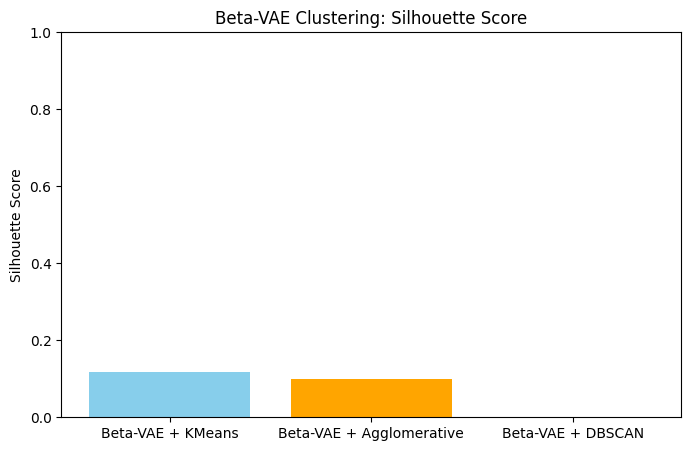

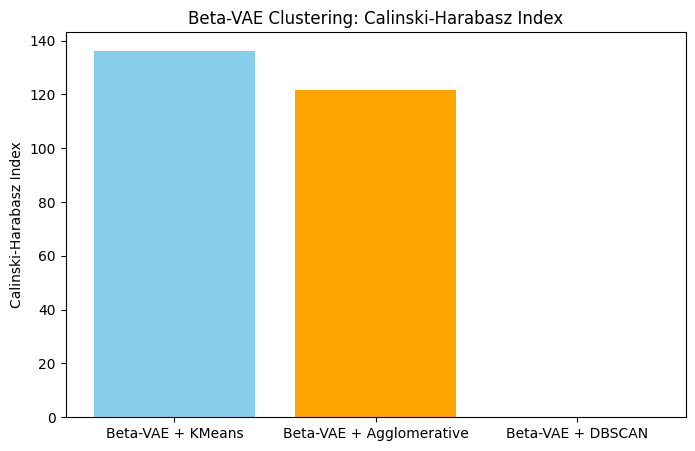

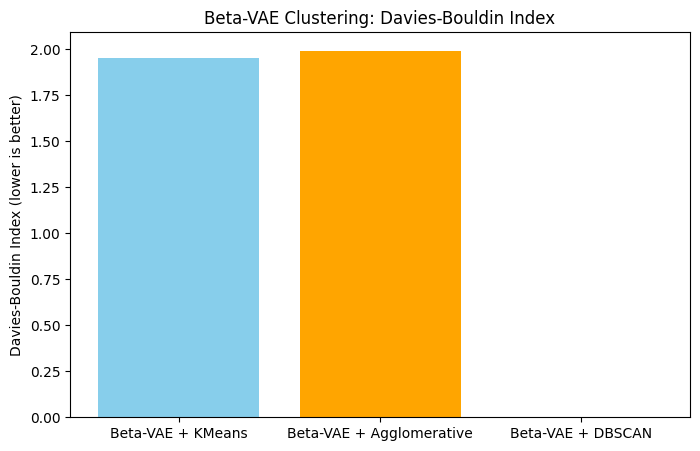

In [41]:
import matplotlib.pyplot as plt

methods = ["Beta-VAE + KMeans", "Beta-VAE + Agglomerative", "Beta-VAE + DBSCAN"]

# Use the metrics you computed earlier
sil_scores = [sil_k, sil_a, sil_db]
ch_scores  = [ch_k, ch_a, ch_db]
db_scores  = [db_k, db_a, db_db]

# Silhouette Score
plt.figure(figsize=(8,5))
plt.bar(methods, sil_scores, color=['skyblue', 'orange', 'green'])
plt.ylabel("Silhouette Score")
plt.title("Beta-VAE Clustering: Silhouette Score")
plt.ylim(0, 1)
plt.show()

# Calinski-Harabasz Index
plt.figure(figsize=(8,5))
plt.bar(methods, ch_scores, color=['skyblue', 'orange', 'green'])
plt.ylabel("Calinski-Harabasz Index")
plt.title("Beta-VAE Clustering: Calinski-Harabasz Index")
plt.show()

# Davies-Bouldin Index
plt.figure(figsize=(8,5))
plt.bar(methods, db_scores, color=['skyblue', 'orange', 'green'])
plt.ylabel("Davies-Bouldin Index (lower is better)")
plt.title("Beta-VAE Clustering: Davies-Bouldin Index")
plt.show()


In [42]:
min_len = min(len(df), len(latent_features))
df = df.iloc[:min_len].reset_index(drop=True)
latent_features = latent_features[:min_len]
kmeans_labels = kmeans_labels[:min_len]
agglo_labels = agglo_labels[:min_len]
dbscan_labels = dbscan_labels[:min_len]


In [43]:
import pandas as pd
import numpy as np

# Make sure your latent_features and df are aligned
# latent_features: output of Beta-VAE encoder (num_songs, latent_dim)
# df: your original dataframe with song identifiers and genre labels

# Create clustering matrix
clustering_matrix = pd.DataFrame({
    'id': df['id'],             # or 'title' if you prefer
    'true_genre': df['genre'],  # optional
    'beta_vae_kmeans': kmeans_labels,
    'beta_vae_agglo': agglo_labels,
    'beta_vae_dbscan': dbscan_labels
})

# Save CSV
clustering_matrix.to_csv("clustering_matrix_hard.csv", index=False)

print("✅ clustering_matrix_hard.csv created successfully!")
clustering_matrix.head()


✅ clustering_matrix_hard.csv created successfully!


,id,true_genre,beta_vae_kmeans,beta_vae_agglo,beta_vae_dbscan
0,711734,country,4,1,0
1,82203,country,4,4,0
2,445332,country,1,3,0
3,541844,country,2,0,0
4,228626,country,2,2,0
